# Modelling IGF1 intracellular signaling using CORNETO
In this notebook we use the advanced CARNIVAL implementation available in CORNETO to infer the intracellular signaling network from IGF1 to TFs to understand how IGF1 might be signaling inside the cardiomyocyte.

- **Parameter Sensitivity**: Alterations in solver settings, threshold values, or choice of prior-knowledge networks can materially affect the inferred network.

- **Data Dependence**: The characteristics of your dataset—experimental design, sample size, preprocessing, and normalization—will directly influence model outputs.

- **Knowledge-Base Limitations**: Underlying pathway repositories may exhibit incomplete coverage and annotation biases.

Each network generated by CARNIVAL should be regarded as a potential, simplified hypothesis of the real signalling.

## Data description
The starting point for analysis is the differentially gene expression results obtained by DESeq2. Two groups are compared: IGF1 vs Control. Both groups are neonatal rat ventricular cardiomyocytes incubated with IGF1 or Control solution for 48. Originally, the sample numbers were n = 3 for both groups.


In [1]:
import gzip
import os
import shutil
import tempfile
import urllib.request
import pandas as pd

# https://decoupler-py.readthedocs.io
import decoupler as dc
import numpy as np

# https://omnipathdb.org/
import omnipath as op
import liana as li

# Pydeseq for differential expression analysis
#from pydeseq2.dds import DefaultInference, DeseqDataSet
#from pydeseq2.ds import DeseqStats

# https://corneto.org
import corneto as cn
import graphviz
#import networkx as nx

/home/hd/hd_hd/hd_kd353/miniforge3/envs/corneto/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-09-29 17:37:51 | [INFO] Downloading data from `https://omnipathdb.org/queries/enzsub?format=json`
2026-09-29 17:37:51 | [INFO] Downloading data from `https://omnipathdb.org/queries/interactions?format=json`
2026-09-29 17:37:51 | [INFO] Downloading data from `https://omnipathdb.org/queries/complexes?format=json`
2026-09-29 17:37:51 | [INFO] Downloading data from `https://omnipathdb.org/queries/annotations?format=json`
2026-09-29 17:37:51 | [INFO] Downloading data from `https://omnipathdb.org/queries/intercell?format=json`
2026-09-29 17:37:51 | [INFO] Downloading data from `https://omnipathdb.org/about?format=text`


In [2]:
max_time = 500
seeds = [i for i in range(100)] # We will run corneto 100 times with different seeds to get a distribution of solutions and select edges that appear in > 50% of runs.

In [4]:
project_dir = "/mnt/sds-hd/sd22b002/projects/ines/axl_networks"
data_dir = os.path.join(project_dir, "results/igf1/pydeseq2")
results_dir = os.path.join(project_dir, "results/igf1/corneto")

## Load the differentially expressed genes and prepare them for enrichment analysis

In [5]:
results_df = pd.read_csv(f'{data_dir}/GSE153763_IGF1_IGF1_vs_Control_deseq2.csv', index_col=0)
results_df.index.name = None
results_df

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
Myom2,36030.155646,-2.505654,0.062380,-40.167435,0.000000e+00,0.000000e+00
Kcnip2,3995.226303,-3.361730,0.087322,-38.498136,0.000000e+00,0.000000e+00
Ckmt2,921.634587,2.956864,0.090136,32.804453,5.087165e-236,2.733164e-232
Scd2,8375.788696,1.879721,0.060420,31.111016,1.709127e-212,6.886925e-209
Eno3,3508.930141,1.920921,0.067793,28.335119,1.276793e-176,4.115870e-173
...,...,...,...,...,...,...
Zfp808,7.159178,-0.155466,0.706745,-0.219975,8.258908e-01,NaN
Zfp950l14,5.754366,0.367850,0.795391,0.462477,6.437396e-01,NaN
Zfp950l6,6.608516,-0.273199,0.785168,-0.347949,7.278784e-01,NaN
Zglp1,6.208929,-0.065834,0.719798,-0.091462,9.271256e-01,NaN


In [13]:
# Translate to human for compatibilities downstream
rat_genes = list(set(results_df.index))

# Translate to human
map_df = pd.read_csv(f'{project_dir}/reference/human_rat_hcop_fifteen_column.txt', sep = '\t')
map_df = map_df[['rat_symbol', 'human_symbol']]

map_df = map_df[map_df['rat_symbol'].isin(rat_genes)]

# Clean up: remove genes without an ortholog in human
map_df = map_df[map_df['human_symbol'] != '-']

# Clean up: keep unique human genes (remove all human duplicated symbols to keep 1:1 orthologs)
map_df = map_df[~map_df.duplicated(subset='human_symbol', keep=False)]

map_df

,rat_symbol,human_symbol
308,A2m,A2M
314,A3galt2,A3GALT2
315,A4galt,A4GALT
317,Aaas,AAAS
318,Aacs,AACS
...,...,...
42583,Zyg11a,ZYG11A
42584,Zyg11b,ZYG11B
42585,Zyx,ZYX
42586,Zzef1,ZZEF1


In [14]:
# Check number of shared genes between results_df and map_df
shared_genes = set(results_df.index).intersection(set(map_df['rat_symbol']))
print(f"Number of shared genes between results_df and map_df: {len(shared_genes)}")

Number of shared genes between results_df and map_df: 9095


In [15]:
results_df_human = (
    results_df
    .merge(map_df[['rat_symbol', 'human_symbol']], left_index=True, right_on='rat_symbol', how='inner')
    .set_index('human_symbol')
    .drop(columns='rat_symbol')
)
results_df_human.index.name = None
results_df_human


,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
KCNIP2,3995.226303,-3.361730,0.087322,-38.498136,0.000000e+00,0.000000e+00
CKMT2,921.634587,2.956864,0.090136,32.804453,5.087165e-236,2.733164e-232
PLA2G7,1674.821853,-2.089693,0.076517,-27.310218,3.207764e-164,8.617123e-161
TXNIP,22111.487354,-1.415875,0.059686,-23.721996,2.138382e-124,4.923777e-121
CCNB1,1593.431372,1.944063,0.086427,22.493832,4.769735e-112,8.542066e-109
...,...,...,...,...,...,...
XIRP2,6418.253245,2.212822,0.973655,2.272695,NaN,NaN
XPNPEP2,5.225249,0.206486,0.766454,0.269405,7.876182e-01,NaN
ZFHX4,4.761900,0.155910,0.824689,0.189053,8.500514e-01,NaN
AMER2,5.619746,0.221284,0.769200,0.287680,7.735915e-01,NaN


In [16]:
data = results_df_human[["stat"]].T.rename(index={"stat": "IGF1.vs.Control"})
data

,KCNIP2,CKMT2,PLA2G7,TXNIP,CCNB1,ATP1A2,FCHO1,RORC,ARRDC3,MASP1,...,EPPIN,EPPIN-WFDC6,WNT10B,WNT16,WNT6,XIRP2,XPNPEP2,ZFHX4,AMER2,ZGLP1
IGF1.vs.Control,-38.498136,32.804453,-27.310218,-23.721996,22.493832,21.04704,-20.125905,-20.125905,-20.078554,-19.988039,...,0.2791,0.2791,-0.748084,0.814632,-0.297716,2.272695,0.269405,0.189053,0.28768,-0.091462


## Estimation of Transcription Factor activities with Deocupler and CollecTRI

In [17]:
# Retrieve CollecTRI gene regulatory network (through Omnipath).
# These are regulons that we will use for enrichment tests
# to infer TF activities
collectri = dc.op.collectri(organism="human")
collectri

,source,target,weight,resources,references,sign_decision
0,MYC,TERT,1.0,DoRothEA-A;ExTRI;HTRI;NTNU.Curated;Pavlidis202...,10022128;10491298;10606235;10637317;10723141;1...,PMID
1,SPI1,BGLAP,1.0,ExTRI,10022617,default activation
2,SMAD3,JUN,1.0,ExTRI;NTNU.Curated;TFactS;TRRUST,10022869;12374795,PMID
3,SMAD4,JUN,1.0,ExTRI;NTNU.Curated;TFactS;TRRUST,10022869;12374795,PMID
4,STAT5A,IL2,1.0,ExTRI,10022878;11435608;17182565;17911616;22854263;2...,default activation
...,...,...,...,...,...,...
42985,NFKB,hsa-miR-143-3p,1.0,ExTRI,19472311,default activation
42986,AP1,hsa-miR-206,1.0,ExTRI;GEREDB;NTNU.Curated,19721712,PMID
42987,NFKB,hsa-miR-21,1.0,ExTRI,20813833;22387281,default activation
42988,NFKB,hsa-miR-224-5p,1.0,ExTRI,23474441;23988648,default activation


In [19]:
# Run
tf_acts, tf_padj = dc.mt.ulm(data=data, net=collectri)

# Save results as df
tf_results = pd.DataFrame({
    'TF': tf_acts.columns,
    'activity': tf_acts.iloc[0].values,
    'padj': tf_padj.iloc[0].values,
})

tf_results.to_csv(f'{results_dir}/IGF1_vs_Control_collectri_results.csv', index=False)

# Filter by sign padj
msk = (tf_padj.T < 0.05).iloc[:, 0]
tf_acts = tf_acts.loc[:, msk]

tf_acts

,ARID3A,CREBBP,CTNNB1,E2F1,E2F2,E2F3,E2F4,FOXM1,FOXO1,FOXO3,...,SPI1,SREBF1,SREBF2,TFAP2B,TFDP1,THRA,TP53,USF1,ZBTB16,ZNF331
IGF1.vs.Control,4.055871,3.733946,-4.274074,5.117898,3.502598,4.887899,6.751806,3.882937,-5.141935,-6.665041,...,-3.089863,4.831904,3.712518,-3.575995,4.078773,-3.50612,-5.982207,-3.822075,-3.321873,-6.265394


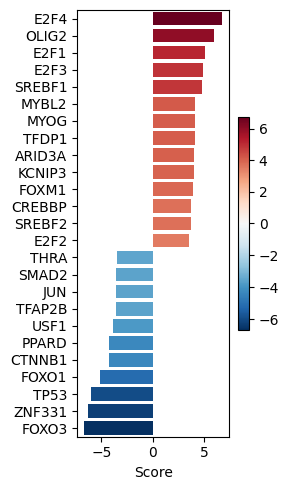

In [20]:
dc.pl.barplot(data=tf_acts, name="IGF1.vs.Control", top=25, figsize=(3, 5))

## Inferring intracellular signaling networks with CARNIVAL and CORNETO

CORNETO is a unified framework for knowledge-driven network inference. It includes a very flexible implementation of CARNIVAL that expands its original capabilities. We will see how to use it under different assumptions to extract a network from a prior knowledge network and a set of potential receptors + our estimated TFs

Installed version: v1.0.0b7
Available backends: CVXPY v1.8.2, PICOS v2.6.2
Default backend (corneto.opt): CVXPY
Installed solvers: CLARABEL, CVXOPT, GLPK, GLPK_MI, GUROBI, HIGHS, OSQP, SCIP, SCIPY, SCS
Plot backend (default): auto -> graphviz
Available plot backends: graphviz v0.21; networkx v3.6.1+mpl v3.10.8; graphviz-wasm
Installed path: /home/hd/hd_hd/hd_kd353/miniforge3/envs/corneto/lib/python3.12/site-packages/corneto
Repository: https://github.com/saezlab/corneto
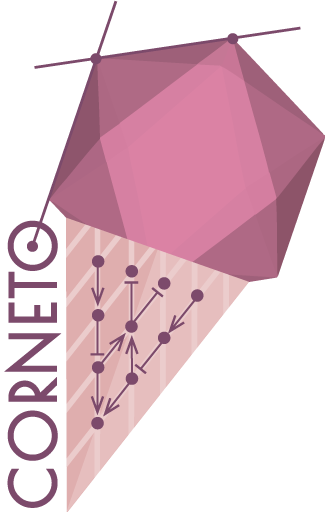

In [21]:
cn.info()

In [22]:
from corneto.methods.future import CarnivalFlow

CarnivalFlow.show_references()

- Pablo Rodriguez-Mier, Martin Garrido-Rodriguez, Attila Gabor, Julio Saez-Rodriguez. Unified knowledge-driven network inference from omics data. bioRxiv, pp. 10 (2024).
 - Anika Liu, Panuwat Trairatphisan, Enio Gjerga, Athanasios Didangelos, Jonathan Barratt, Julio Saez-Rodriguez. From expression footprints to causal pathways: contextualizing large signaling networks with CARNIVAL. NPJ systems biology and applications, Vol. 5, No. 1, pp. 40 (2019).

In [23]:
# We get only interactions from SIGNOR http://signor.uniroma2.it/
pkn = op.interactions.OmniPath.get(databases=["SIGNOR"], genesymbols=True)
pkn = pkn[pkn.consensus_direction == True]
pkn.head()

,source,target,source_genesymbol,target_genesymbol,is_directed,is_stimulation,is_inhibition,consensus_direction,consensus_stimulation,consensus_inhibition,sources,references,curation_effort,n_sources,n_primary_sources,n_references,references_stripped
0,Q13976,Q13507,PRKG1,TRPC3,True,False,True,True,False,True,PhosphoSite_MIMP;MIMP;HPRD_MIMP;PhosphoSite_no...,SIGNOR:14983059;HPRD:14983059;KEA:14983059;Pro...,7,15,8,2,14983059;16331690
1,P06241,Q9Y210,FYN,TRPC6,True,True,False,True,True,False,TRIP;PhosphoPoint;SIGNOR;HPRD;SPIKE_LC,TRIP:14761972;HPRD:14761972;SIGNOR:21471003;SP...,4,5,4,3,14761972;16713569;21471003
2,Q13976,Q9Y210,PRKG1,TRPC6,True,False,True,True,False,True,Sparser_ProtMapper;phosphoELM_MIMP;PhosphoSite...,TRIP:18617565;SIGNOR:19961855;ProtMapper:21402...,4,11,5,4,18617565;19961855;21402151;24740790
3,P12931,Q9Y210,SRC,TRPC6,True,True,False,True,True,False,TRIP;PhosphoPoint;SIGNOR;ProtMapper;HPRD;REACH...,TRIP:14761972;HPRD:14761972;SIGNOR:21471003;Pr...,4,6,5,2,14761972;21471003
4,Q13976,Q9HCX4,PRKG1,TRPC7,True,True,False,True,True,False,iPTMnet;TRIP;SIGNOR;ProtMapper;SIGNOR_ProtMapper,SIGNOR:21402151;ProtMapper:21402151;TRIP:21402151,3,5,4,1,21402151


In [24]:
pkn["interaction"] = pkn["is_stimulation"].astype(int) - pkn["is_inhibition"].astype(int)
sel_pkn = pkn[["source_genesymbol", "interaction", "target_genesymbol"]]
sel_pkn

,source_genesymbol,interaction,target_genesymbol
0,PRKG1,-1,TRPC3
1,FYN,1,TRPC6
2,PRKG1,-1,TRPC6
3,SRC,1,TRPC6
4,PRKG1,1,TRPC7
...,...,...,...
65526,LPAR5,1,GNA13
65527,PRKCA,-1,ITPKB
65528,UBXN1,1,NGLY1
65529,CCNC,-1,NOTCH1


In [25]:
# We create the CORNETO graph by importing the edges and interaction
from corneto.io import load_graph_from_sif_tuples

G = load_graph_from_sif_tuples([(r[0], r[1], r[2]) for _, r in sel_pkn.iterrows() if r[1] != 0])
G.shape

/tmp/ipykernel_1151296/1534210904.py:4: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`


(6092, 63820)

In [26]:
# As measurements, we take the estimated TFs, we will filter out TFs with p-val > 0.001
significant_tfs = tf_acts[tf_padj <= 0.05].T.dropna().sort_values(by="IGF1.vs.Control", ascending=False)
significant_tfs

,IGF1.vs.Control
E2F4,6.751806
OLIG2,5.997314
E2F1,5.117898
E2F3,4.887899
SREBF1,4.831904
MYBL2,4.147123
MYOG,4.083543
TFDP1,4.078773
ARID3A,4.055871
KCNIP3,4.005680


In [27]:
# We keep only the ones in the PKN graph
measurements = significant_tfs.loc[significant_tfs.index.intersection(G.V)].to_dict()["IGF1.vs.Control"]
measurements

{'E2F1': 5.117898097624957,
 'E2F3': 4.887899030158391,
 'SREBF1': 4.831904077702853,
 'MYBL2': 4.147122994731971,
 'MYOG': 4.08354289555497,
 'TFDP1': 4.078773247861361,
 'ARID3A': 4.055871452722143,
 'FOXM1': 3.882936871289553,
 'CREBBP': 3.733945659439332,
 'SREBF2': 3.712518179671656,
 'E2F2': 3.5025978149967245,
 'HCFC1': 3.4346489078736373,
 'SMAD3': -3.022771056786106,
 'SPI1': -3.089862682808305,
 'ZBTB16': -3.321872641728577,
 'HBP1': -3.4613000542522556,
 'THRA': -3.5061201691185424,
 'SMAD2': -3.5527872439891968,
 'JUN': -3.5731343033127625,
 'TFAP2B': -3.575995214333062,
 'USF1': -3.8220750876390035,
 'PPARD': -4.272524145338505,
 'CTNNB1': -4.274074222858754,
 'FOXO1': -5.141934659320538,
 'TP53': -5.9822066355353245,
 'FOXO3': -6.6650405925986185}

In [28]:
# Check that AXL is in graph
"IGF1" in G.V

True

In [29]:
# Here we pass the receptors. We're going to use IGF1 as receptor. We set it as active because the treatment is IGF1 activation, and IGF1 is overexpressed in the treatment group.
inputs = {"IGF1": 1}  # 1=up, -1=down
inputs

{'IGF1': 1}

In [30]:
# Create the dataset in standard format
carnival_data = dict()
for inp, v in inputs.items():
    carnival_data[inp] = dict(value=v, role="input", mapping="vertex")
for out, v in measurements.items():
    carnival_data[out] = dict(value=v, role="output", mapping="vertex")
data = cn.Data.from_cdict({"sample1": carnival_data})
data

Data(n_samples=1, n_feats=[27])

### CARNIVAL
We will use now the CARNIVAL, as implemented with CORNETO, with a penalty to regularize the solution. For hypothesis exploration, we can try different values and manually inspect the solutions. We are going to penalize also the selection of indirect rules, to simplify the solution. These rules are:
- A -> B in the PKN, and we observe B is downregulated, we explain it with downregulation of its upstream gene A
- A -| B in the PKN, and we observe B is upregulated, we explain it with downregulation of A

In [31]:
carnival = CarnivalFlow(lambda_reg=1.0, indirect_rule_penalty=10)
P = carnival.build(G, data)
P.expr

Unreachable vertices for sample: 0


{'_flow': _flow: Variable((5137,), _flow),
 'edge_activates': edge_activates: Variable((5137, 1), edge_activates, boolean=True),
 'edge_inhibits': edge_inhibits: Variable((5137, 1), edge_inhibits, boolean=True),
 '_dag_layer': _dag_layer: Variable((1262, 1), _dag_layer),
 'const0x242c714f20349de': const0x242c714f20349de: Constant(CONSTANT, NONNEGATIVE, (1262, 5137)),
 'const0xd1d322e53355f0a': const0xd1d322e53355f0a: Constant(CONSTANT, NONNEGATIVE, (1262, 5137)),
 'flow': _flow: Variable((5137,), _flow),
 'vertex_value': Expression(AFFINE, UNKNOWN, (1262, 1)),
 'vertex_activated': Expression(AFFINE, NONNEGATIVE, (1262, 1)),
 'vertex_inhibited': Expression(AFFINE, NONNEGATIVE, (1262, 1)),
 'edge_value': Expression(AFFINE, UNKNOWN, (5137, 1)),
 'edge_has_signal': Expression(AFFINE, NONNEGATIVE, (5137, 1)),
 'vertex_max_depth': _dag_layer: Variable((1262, 1), _dag_layer)}

In [32]:
results = {}

# We run corneto 100 times, each with a different seed. Then we will select edges that appear in > 50% of runs.
for seed in seeds:
    print(f"Running corneto with seed {seed}...")
    P.solve(solver="highs", max_seconds=60, verbosity=0, random_seed=seed);
    
    for o in P.objectives:
        print(o.name, "->", o.value)
    
    # Extract the selected edges
    sol_edges = np.flatnonzero(np.abs(P.expr.edge_value.value) > 0.5)
    carnival.processed_graph.plot_values(
        vertex_values=P.expr.vertex_value.value,
        edge_values=P.expr.edge_value.value,
        edge_indexes=sol_edges,
    )

    dot_source = carnival.processed_graph.plot_values(
        vertex_values=P.expr.vertex_value.value,
        edge_values=P.expr.edge_value.value,
        edge_indexes=sol_edges,
    )

    # inject smaller font size
    dot_source = dot_source.replace(
        'node [fixedsize="true"];',
        'node [fixedsize="true", fontsize="8"]; edge [fontsize="8"];'
    )

    # display(graphviz.Source(dot_source))

    # Extracting the solution graph
    G_sol = carnival.processed_graph.edge_subgraph(sol_edges)
    print(G_sol.shape)


    # Get node df of final filtered graph solution
    node_df = pd.DataFrame(P.expr.vertex_value.value, index=carnival.processed_graph.V, columns=["node_activity"])
    node_df_filt = node_df.loc[node_df.index.isin(G_sol.V)]
    node_df_filt = node_df_filt.reset_index(names='gene_symbol')

    # Get edge df of final filtered graph solution, reshaped to From, To, edge_activity
    edge_df = pd.DataFrame(P.expr.edge_value.value, index=carnival.processed_graph.E, columns=["edge_activity"])
    edge_df_filtered = edge_df.loc[edge_df.index.isin(G_sol.E)].reset_index()
    edge_df_filtered.columns = ["From", "To", "edge_activity"]

    # Save into dictionary
    results[seed] = {"nodes": node_df, "edges": edge_df}


Running corneto with seed 0...
error_sample1_0 -> 22.648160166899995
penalty_indirect_rules_0 -> [0.]
regularization_edge_has_signal -> 35.0
(35, 35)
Running corneto with seed 1...
error_sample1_0 -> 22.6481601669
penalty_indirect_rules_0 -> [0.]
regularization_edge_has_signal -> 35.0
(35, 35)
Running corneto with seed 2...


/home/hd/hd_hd/hd_kd353/miniforge3/envs/corneto/lib/python3.12/site-packages/corneto/backend/_cvxpy_backend.py:206: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.


error_sample1_0 -> 22.6481601669
penalty_indirect_rules_0 -> [0.]
regularization_edge_has_signal -> 35.0
(35, 35)
Running corneto with seed 3...
error_sample1_0 -> 22.6481601669
penalty_indirect_rules_0 -> [0.]
regularization_edge_has_signal -> 35.0
(35, 35)
Running corneto with seed 4...
error_sample1_0 -> 22.6481601669
penalty_indirect_rules_0 -> [0.]
regularization_edge_has_signal -> 35.0
(35, 35)
Running corneto with seed 5...


/home/hd/hd_hd/hd_kd353/miniforge3/envs/corneto/lib/python3.12/site-packages/corneto/backend/_cvxpy_backend.py:206: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.


error_sample1_0 -> 22.6481601669
penalty_indirect_rules_0 -> [0.]
regularization_edge_has_signal -> 38.0
(38, 38)
Running corneto with seed 6...
error_sample1_0 -> 22.6481601669
penalty_indirect_rules_0 -> [0.]
regularization_edge_has_signal -> 35.0
(35, 35)
Running corneto with seed 7...


...

error_sample1_0 -> 22.6481601669
penalty_indirect_rules_0 -> [0.]
regularization_edge_has_signal -> 35.0
(35, 35)
Running corneto with seed 97...


/home/hd/hd_hd/hd_kd353/miniforge3/envs/corneto/lib/python3.12/site-packages/corneto/backend/_cvxpy_backend.py:206: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.


error_sample1_0 -> 22.6481601669
penalty_indirect_rules_0 -> [0.]
regularization_edge_has_signal -> 36.0
(36, 36)
Running corneto with seed 98...


/home/hd/hd_hd/hd_kd353/miniforge3/envs/corneto/lib/python3.12/site-packages/corneto/backend/_cvxpy_backend.py:206: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.


error_sample1_0 -> 22.6481601669
penalty_indirect_rules_0 -> [0.]
regularization_edge_has_signal -> 35.0
(35, 35)
Running corneto with seed 99...
error_sample1_0 -> 22.648160166899995
penalty_indirect_rules_0 -> [0.]
regularization_edge_has_signal -> 35.0
(35, 35)


In [33]:
n_runs = len(results)

def format_side(side):
    """Turn a tuple of node names into a clean comma-joined string, or '' if empty."""
    if not side:
        return ""
    return ",".join(side)

def get_nodes(side):
    """Flatten a tuple of node names into individual node strings."""
    return list(side) if side else []

# Long-format edge table across all runs
edge_frames = []
for seed, res in results.items():
    ed = res["edges"].copy()
    ed["seed"] = seed
    ed["edge"] = ed.index
    edge_frames.append(ed.reset_index(drop=True))

edges_long = pd.concat(edge_frames, ignore_index=True)
edges_long["present"] = edges_long["edge_activity"].abs() > 0.5

# Frequency and mean activity per edge
edge_summary = (
    edges_long.groupby("edge")
    .agg(
        frequency=("present", "mean"),
        mean_activity=("edge_activity", "mean"),
        n_present=("present", "sum"),
    )
    .reset_index()
)

# Keep only edges present in >50% of runs
results_edge_df = (
    edge_summary[edge_summary["frequency"] > 0.5]
    .sort_values("frequency", ascending=False)
    .reset_index(drop=True)
)

# Add readable From/To columns
results_edge_df["From"] = results_edge_df["edge"].apply(lambda e: format_side(e[0]))
results_edge_df["To"] = results_edge_df["edge"].apply(lambda e: format_side(e[1]))
results_edge_df = results_edge_df.drop(columns="edge")[
    ["From", "To", "frequency", "mean_activity", "n_present"]
]

# Get the set of nodes involved in these edges (flattening both sides)
involved_nodes = set()
for e in edge_summary.loc[edge_summary["frequency"] > 0.5, "edge"]:
    involved_nodes.update(get_nodes(e[0]))
    involved_nodes.update(get_nodes(e[1]))

# Long-format node table, averaged over all 100 runs
node_frames = []
for seed, res in results.items():
    nd = res["nodes"].copy()
    nd["seed"] = seed
    nd["node"] = nd.index
    node_frames.append(nd.reset_index(drop=True))

nodes_long = pd.concat(node_frames, ignore_index=True)

node_summary = (
    nodes_long.groupby("node")["node_activity"]
    .mean()
    .reset_index()
    .rename(columns={"node_activity": "mean_activity"})
)

# Filter to nodes involved in the selected edges
results_node_df = node_summary[node_summary["node"].isin(involved_nodes)].reset_index(drop=True)
results_node_df = results_node_df.rename(columns={"node": "Node"})

In [34]:
results_edge_df.to_csv(f"{results_dir}/IGF1_vs_Control_corneto_edges.csv", index=False)
results_node_df.to_csv(f"{results_dir}/IGF1_vs_Control_corneto_nodes.csv", index=False)

In [35]:
results_node_df

,Node,mean_activity
0,AKT1,0.80
1,ARID3A,0.98
2,CDK2,0.98
3,CHEK1,0.98
4,CHUK,0.64
5,CREBBP,0.98
6,E2F1,0.98
7,E2F3,0.98
8,FBXW7,0.51
9,FOXM1,0.98


In [36]:
# Annotate node df with log2FC results from DESeq2
results_node_df = results_node_df.merge(
    results_df_human[["log2FoldChange", "padj"]],
    left_on="Node",
    right_index=True,
    how="left",
)
results_node_df = results_node_df.rename(columns={'log2FoldChange': 'deseq2.log2FC', 'padj': 'deseq2.padj', 'mean_activity': 'corneto_node_mean_activity'})

# Annotate node df with TF activity predictions from decoupler
results_node_df = results_node_df.merge(
    tf_results.rename(columns={"activity": "collectri.activity", "padj": "collectri.padj"}),
    left_on="Node",
    right_on="TF",
    how="left",
)
results_node_df = results_node_df.drop(columns="TF")
results_node_df.to_csv(f"{results_dir}/IGF1_vs_Control_corneto_nodes_annotated.csv", index=False)
results_node_df

,Node,corneto_node_mean_activity,deseq2.log2FC,deseq2.padj,collectri.activity,collectri.padj
0,AKT1,0.80,NaN,NaN,NaN,NaN
1,ARID3A,0.98,-0.249472,3.548777e-01,4.055871,2.015870e-03
2,CDK2,0.98,0.124928,1.610292e-01,NaN,NaN
3,CHEK1,0.98,0.022568,8.074154e-01,NaN,NaN
4,CHUK,0.64,NaN,NaN,NaN,NaN
5,CREBBP,0.98,-0.125689,1.230579e-01,3.733946,5.994532e-03
6,E2F1,0.98,0.663599,7.003564e-09,5.117898,2.700095e-05
7,E2F3,0.98,NaN,NaN,4.887899,7.771152e-05
8,FBXW7,0.51,0.250609,4.079507e-03,NaN,NaN
9,FOXM1,0.98,1.054462,3.995122e-37,3.882937,3.671118e-03


## Session info

In [37]:
cn.__version__

'1.0.0b7'

In [38]:
dc.__version__

'2.1.4'

In [39]:
op.__version__

'1.0.12'

In [40]:
li.__version__

'1.10.0'